# Classifying Fashion-MNIST

Now it's your turn to build and train a neural network. You'll be using the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist), a drop-in replacement for the MNIST dataset. MNIST is actually quite trivial with neural networks where you can easily achieve better than 97% accuracy. Fashion-MNIST is a set of 28x28 greyscale images of clothes. It's more complex than MNIST, so it's a better representation of the actual performance of your network, and a better representation of datasets you'll use in the real world.

<img src='assets/fashion-mnist-sprite.png' width=500px>

In this notebook, you'll build your own neural network. For the most part, you could just copy and paste the code from Part 3, but you wouldn't be learning. It's important for you to write the code yourself and get it to work. Feel free to consult the previous notebooks though as you work through this.

First off, let's load the dataset through torchvision.

In [1]:
num_threads = 24
# Device: cpu, xpu, cuda
device = "xpu"

In [2]:
import time
import helper
from torch import nn, optim
import torch.nn.functional as F

In [3]:
import torch
from torchvision import datasets, transforms
import helper

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, \
                                          num_workers = num_threads)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True, \
                                         num_workers = num_threads)

Here we can see one of the images.

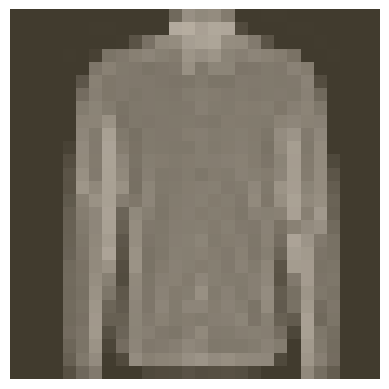

In [4]:
image, label = next(iter(trainloader))
helper.imshow(image[0,:]);

## Building the network

Here you should define your network. As with MNIST, each image is 28x28 which is a total of 784 pixels, and there are 10 classes. You should include at least one hidden layer. We suggest you use ReLU activations for the layers and to return the logits or log-softmax from the forward pass. It's up to you how many layers you add and the size of those layers.

In [5]:
# TODO: Define your network architecture here

model = nn.Sequential(nn.Linear(784, 128),
                      nn.ReLU(),
                      nn.Linear(128, 64),
                      nn.ReLU(),
                      nn.Linear(64, 10),
                      nn.LogSoftmax(dim=1)).to(device)

In [6]:
model

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): LogSoftmax(dim=1)
)

# Train the network

Now you should create your network and train it. First you'll want to define [the criterion](http://pytorch.org/docs/master/nn.html#loss-functions) ( something like `nn.CrossEntropyLoss`) and [the optimizer](http://pytorch.org/docs/master/optim.html) (typically `optim.SGD` or `optim.Adam`).

Then write the training code. Remember the training pass is a fairly straightforward process:

* Make a forward pass through the network to get the logits 
* Use the logits to calculate the loss
* Perform a backward pass through the network with `loss.backward()` to calculate the gradients
* Take a step with the optimizer to update the weights

By adjusting the hyperparameters (hidden units, learning rate, etc), you should be able to get the training loss below 0.4.

In [7]:
# TODO: Create the network, define the criterion and optimizer

criterion = nn.NLLLoss().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.003)

In [8]:
# TODO: Train the network here

tic = time.time()

epochs = 5
for e in range(epochs):
    running_loss = 0
    for images, labels in trainloader:
        # Flatten MNIST images into a 784 long vector
        images = images.view(images.shape[0], -1)
        # Send dataset to device
        images = images.to(device)
        labels = labels.to(device)
        
        # Clear the gradients, do this because gradients are accumulated
        optimizer.zero_grad()
        
        # Make a forward pass through the network
        output = model.forward(images)
        # Use the network output to calculate the loss
        loss = criterion(output, labels)
        # Perform a backward pass through the network with loss.backward() 
        # to calculate the gradients
        loss.backward()
        # Take a step with the optimizer to update the weights
        optimizer.step()
        
        running_loss += loss.item()
    else:
        print(f"Training loss: {running_loss/len(trainloader)}")
        
toc = time.time()
print(toc - tic, "second(s)")

Training loss: 1.687312745590454
Training loss: 0.843061852683899
Training loss: 0.6749593740078941
Training loss: 0.6101565796302072
Training loss: 0.5689290906511136
14.07440996170044 second(s)


### Performance Evaluation

**Intel(R) Core(TM) i7-8750H + NVIDIA GeForce® GTX 1060**
 - GPU takes about 23 seconds.
```
    Training loss: 1.7703690136800696
    Training loss: 0.8410069512278795
    Training loss: 0.6661298187938072
    Training loss: 0.6053722685715283
    Training loss: 0.5661624161991229
    23.27823519706726 second(s)
```
 - GPU memory required is 450 MiB.

**Intel® Core™ Ultra 9 Processor 285K + Intel® Arc™ A770 Graphics**
 - GPU with 24 data loader workers and 64 batch size takes about 14 seconds using 10% of CPU and 20% of GPU utilization.
```
    Training loss: 1.6547459670856817
    Training loss: 0.8219003875626684
    Training loss: 0.662114193412795
    Training loss: 0.5978486845488233
    Training loss: 0.557415437723782
    14.014941930770874 second(s)
```
 - Idle power consumption for GPU is 40W and CPU cores only is 2W with CPU total of 10W.
 - Training on GPU power consumption for GPU is 70W and CPU cores only is 23W with CPU total of 36W.

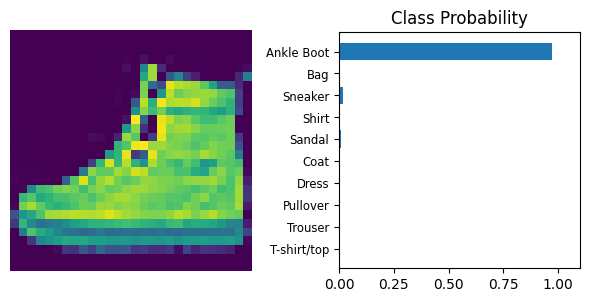

In [11]:
%matplotlib inline

# Test out your network!

dataiter = iter(testloader)
images, labels = next(dataiter)
img = images[0]
# Convert 2D image to 1D vector
img = img.resize_(1, 784)
# Send dataset to device
img = img.to(device)

# TODO: Calculate the class probabilities (softmax) for img
# Turn off gradients to speed up this part
with torch.no_grad():
    logps = model.forward(img)
# Output of the network are logits, need to take softmax for probabilities
ps = F.softmax(logps, dim=1)

# Plot the image and probabilities
helper.view_classify(img.to("cpu").resize_(1, 28, 28), ps.to("cpu"), version='Fashion')